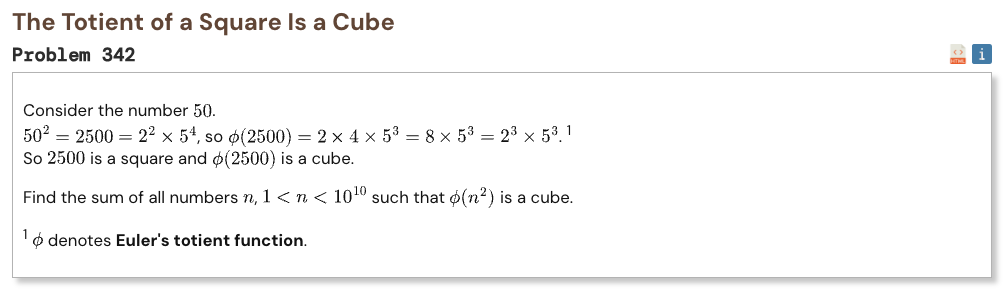

## Initial approach

* track prime exponents only modulo three
* each chosen prime changes the residue state through itself and through one less than itself
* if any residue is nonzero, force the largest missing prime that can fix it
* when all residues are zero, the current base already works
* then multiply by any cubes of already selected primes without breaking the cube condition
* this avoids checking every number below the limit
* use math only for integer square roots

In [1]:
import math

LIMIT = 10 ** 10

def build_spf(limit):
    spf = list(range(limit + 1))

    if limit >= 1:
        spf[1] = 0

    for p in range(2, math.isqrt(limit) + 1):
        if spf[p] != p:
            continue

        for multiple in range(p * p, limit + 1, p):
            if spf[multiple] == multiple:
                spf[multiple] = p

    return spf

def phi(n):
    result = n
    x = n
    p = 2

    while p * p <= x:
        if x % p == 0:
            while x % p == 0:
                x //= p

            result -= result // p

        p = 3 if p == 2 else p + 2

    if x > 1:
        result -= result // x

    return result

def is_perfect_cube(x):
    root = round(x ** (1.0 / 3.0))

    for candidate in range(root - 2, root + 3):
        if candidate >= 0 and candidate ** 3 == x:
            return True

    return False

def upper_bound(arr, value):
    lo = 0
    hi = len(arr)

    while lo < hi:
        mid = (lo + hi) // 2

        if arr[mid] <= value:
            lo = mid + 1
        else:
            hi = mid

    return lo

def solve(limit):
    max_prime = math.isqrt(limit - 1)
    spf = build_spf(max_prime)
    primes = [p for p in range(2, max_prime + 1) if spf[p] == p]
    prime_index = {p: i for i, p in enumerate(primes)}

    factors_mod3 = [()] * (max_prime + 1)

    for p in primes:
        x = p - 1
        factors = []

        while x > 1:
            q = spf[x]
            exponent = 0

            while x % q == 0:
                x //= q
                exponent += 1

            exponent %= 3

            if exponent:
                factors.append((q, exponent))

        factors_mod3[p] = tuple(factors)

    residues = [0] * (max_prime + 1)
    nonzero_primes = set()
    selected_primes = []
    total = 0

    def add_residue(p, delta):
        old = residues[p]
        new = (old + delta) % 3

        if old == 0 and new != 0:
            nonzero_primes.add(p)
        elif old != 0 and new == 0:
            nonzero_primes.remove(p)

        residues[p] = new

    def add_factor_residues(p, sign):
        for q, exponent in factors_mod3[p]:
            add_residue(q, sign * exponent)

    def multiplier_sum(index, current, max_multiplier):
        if index == len(selected_primes):
            return current

        p3 = selected_primes[index] ** 3
        subtotal = 0
        value = current

        while value <= max_multiplier:
            subtotal += multiplier_sum(index + 1, value, max_multiplier)
            value *= p3

        return subtotal

    def add_family(base):
        nonlocal total

        if base > 1:
            total += base * multiplier_sum(0, 1, (limit - 1) // base)

    def include_optional(index, base):
        p = primes[index]

        selected_primes.append(p)
        add_factor_residues(p, 1)
        dfs(index - 1, base * p * p)
        add_factor_residues(p, -1)
        selected_primes.pop()

    def force_prime(index, base):
        p = primes[index]
        residue = residues[p]
        exponent = 3 if residue == 1 else 1
        next_base = base * (p ** exponent)

        if next_base >= limit:
            return

        add_residue(p, -residue)
        selected_primes.append(p)
        add_factor_residues(p, 1)
        dfs(index - 1, next_base)
        add_factor_residues(p, -1)
        selected_primes.pop()
        add_residue(p, residue)

    def dfs(high_index, base):
        if high_index < 0:
            if not nonzero_primes:
                add_family(base)

            return

        max_optional = math.isqrt((limit - 1) // base)
        optional_end = min(high_index, upper_bound(primes, max_optional) - 1)

        if nonzero_primes:
            forced_prime = max(nonzero_primes)
            forced_index = prime_index[forced_prime]

            for index in range(optional_end, forced_index, -1):
                include_optional(index, base)

            force_prime(forced_index, base)
            return

        add_family(base)

        for index in range(optional_end, -1, -1):
            include_optional(index, base)

    dfs(len(primes) - 1, 1)

    return total

assert is_perfect_cube(phi(50 * 50))

In [2]:
%%time
result = solve(LIMIT)
print("Result:", result)

Result: 5943040885644
CPU times: user 60.9 ms, sys: 2.04 ms, total: 63 ms
Wall time: 62.2 ms
